# Initial Setup

In [1]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Download dataset from kaggle and move the file to the current directory
!python download_dataset.py

# Read file into dataframe
dataset_file_name = "Sample - Superstore.csv" 
df = pd.read_csv(dataset_file_name, encoding="latin-1")

Path to dataset files: C:\Users\luand\.cache\kagglehub\datasets\vivek468\superstore-dataset-final\versions\1
Destination path:  C:\Users\luand\Amazon Sales Data Analysis\amazon-sales-data-analysis\Sample - Superstore.csv


# Exploratory Data Analysis

In [2]:
# Show top 5 rows to get an idea of the data and columns
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Check for null values
print(pd.isnull(df).sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## The output above shows that there are 0 null values throughout the data.

In [4]:
# Check uniqueness of product_id
print("Total rows:" ,df.shape[0])
df['Row ID'].value_counts()

Total rows: 9994


Row ID
1       1
2       1
3       1
4       1
5       1
       ..
9990    1
9991    1
9992    1
9993    1
9994    1
Name: count, Length: 9994, dtype: int64

## The output above shows that there are 9994 unique Row IDs, which matches the 9994 total rows, meaning no duplicate rows!

# Data Analysis

## In this section, there are a couple of things I wanted to figure out about the data, the main question I want to figure out is: "What drives profitability in US retail, and where are margins being lost?"

## To gain an idea of an answer to this, I came up with some smaller questions to investigate:
1. What does overall sales and profit look like across the dataset?
2. Which product categories sell the most? and are they actually the most profitable? 
3. Which sub-categories have high sales but negative profit? 
4. Does discount percentage correlate with profit loss? 
5. Which customer segment generates the most revenue and profit?
6. How do sales and profit trend over time per category?
7. Which cities and regions have the highest order volume?
8. What is the average shipping time per city, and does ship mode affect profitability?
9. Can we predict profits of a category based on discount?

### 1. What does overall sales and profit look like across the dataset?

In [5]:
sales = df['Sales'].sum()
profit = df['Profit'].sum()
print(f"{"Overall Sales:":15}{sales:>10,} \n{"Overall Profit:":17}{profit:>10,}")

Overall Sales: 2,297,200.8603 
Overall Profit:  286,397.0217


### 2. Which product categories sell the most? and are they actually the most profitable? 

In [9]:
df_product_groups = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print(df_product_groups)

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


In [10]:
df_product_profits = df.groupby('Category')[['Profit']].sum().sort_values('Profit', ascending=False)
print(df_product_profits)

                      Profit
Category                    
Technology       145454.9481
Office Supplies  122490.8008
Furniture         18451.2728


### Given the results above, we can see that Technology, Furniture, and Office Supplies are the categories that sell the most. It also turns out that these categories are also the most profitable.

### 3. Which sub-categories have high sales but negative profit? 

In [15]:
df_sub_categories = df.groupby('Sub-Category')[['Sales', 'Profit']].sum()
high_sales_neg_profit = df_sub_categories[df_sub_categories['Profit'] < 0].sort_values('Sales', ascending=False)
print(high_sales_neg_profit)

                    Sales      Profit
Sub-Category                         
Tables        206965.5320 -17725.4811
Bookcases     114879.9963  -3472.5560
Supplies       46673.5380  -1189.0995


### From the result above, we can see that the sub-categories with high sales but negative profit are: Tables, Bookcases, and Supplies

### 4. Does discount percentage correlate with profit loss? 

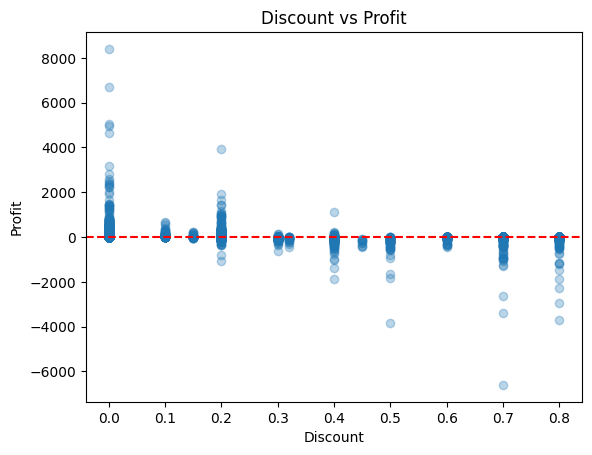

In [16]:
plt.scatter(df['Discount'], df['Profit'], alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()

In [17]:
correlation = df['Discount'].corr(df['Profit'])
print(f"Correlation: {correlation:.4f}")

Correlation: -0.2195


### From the plot above, discounts beyond 30% appear to be a profit killer as profits start going into the negatives at this point. The business is likely selling at a loss to move inventory, which isn't sustainable.

### 5. Which customer segment generates the most revenue and profit?

In [18]:
df_customer_segment = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
print(df_customer_segment)

                    Sales       Profit
Segment                               
Consumer     1.161401e+06  134119.2092
Corporate    7.061464e+05   91979.1340
Home Office  4.296531e+05   60298.6785


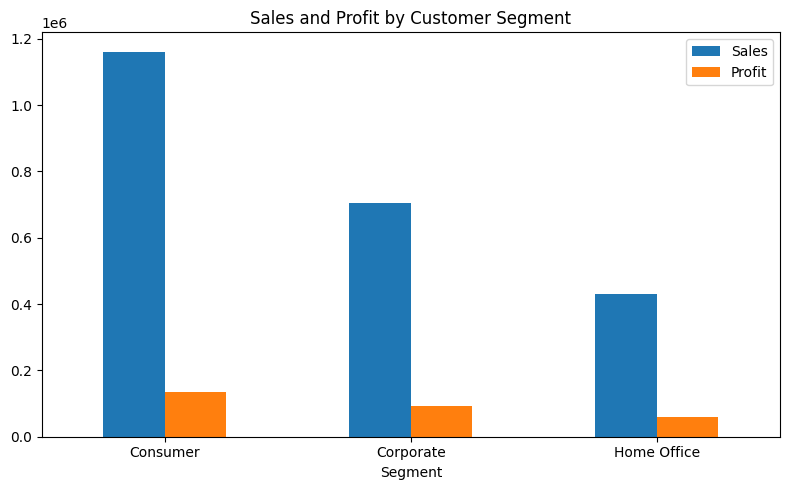

In [19]:
df_customer_segment[['Sales', 'Profit']].plot(kind='bar', figsize=(8,5))
plt.title('Sales and Profit by Customer Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### From the plots above, we can see that the Consumers segment generates the most sales and profit.

### 6. How do sales and profit trend over time per category?

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df_trends = df.groupby(['YearMonth', 'Category'])[['Sales', 'Profit']].sum().reset_index()
print(df_trends)

    YearMonth         Category       Sales     Profit
0     2014-01        Furniture   6242.5250   805.4665
1     2014-01  Office Supplies   4851.0800   788.9506
2     2014-01       Technology   3143.2900   855.7736
3     2014-02        Furniture   1839.6580   120.6917
4     2014-02  Office Supplies   1071.7240   176.0910
..        ...              ...         ...        ...
139   2017-11  Office Supplies  31472.3370  3609.1029
140   2017-11       Technology  49918.7730  5674.9371
141   2017-12        Furniture  31407.4668  1146.7548
142   2017-12  Office Supplies  30436.9420  1774.3132
143   2017-12       Technology  21984.9100  5562.2788

[144 rows x 4 columns]


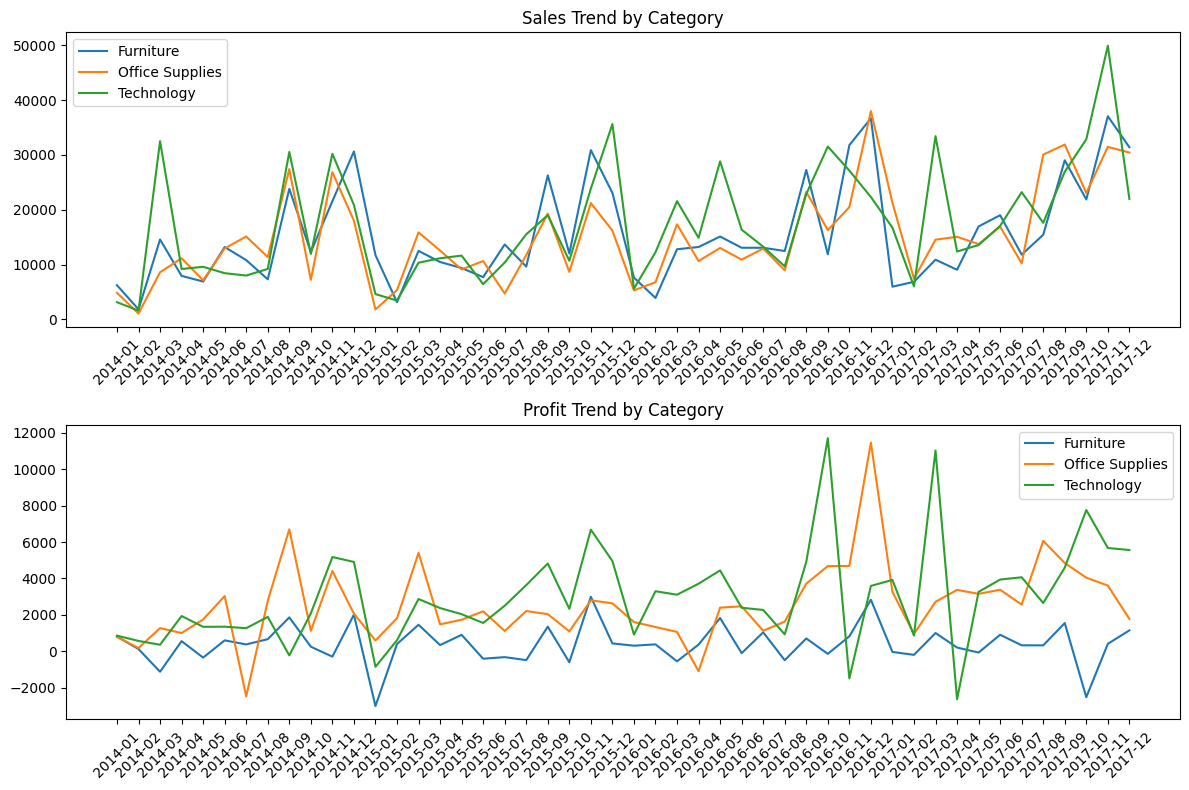

In [21]:
categories = df['Category'].unique()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for category in categories:
    mask = df_trends['Category'] == category
    axes[0].plot(df_trends[mask]['YearMonth'].astype(str), df_trends[mask]['Sales'], label=category)
    axes[1].plot(df_trends[mask]['YearMonth'].astype(str), df_trends[mask]['Profit'], label=category)

axes[0].set_title('Sales Trend by Category')
axes[1].set_title('Profit Trend by Category')

for ax in axes:
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Sales across all three categories show a general upward trend from 2014 to 2017, indicating overall business growth. Technology experiences the most volatile sales with sharp peaks and dips, suggesting it relies on large but infrequent purchases. Office Supplies and Furniture are comparatively more stable in sales volume. A notable spike across all categories is visible toward the end of 2017, possibly indicating strong year-end demand.

### However, when looking at profit, the story changes significantly. Technology is the most profitable category, consistently posting the highest profit peaks throughout the period. Office Supplies maintains steady, positive profit throughout with modest but reliable margins. Furniture is the outlier because despite having comparable sales to the other categories, its profit line repeatedly dips below zero across the entire 4-year period, meaning the business is frequently selling furniture at a loss.

### The key takeaway is that high sales do not guarantee high profit, and Furniture is the clearest example of this. Its persistent negative profit despite decent sales volume strongly suggests over-discounting or high costs eating into margins.

### 7. Which cities and regions have the highest order volume?

In [23]:
df_cities = df.groupby('City')[['Quantity']].sum().sort_values('Quantity', ascending=False)
print(df_cities.head(3))

               Quantity
City                   
New York City      3417
Los Angeles        2879
Philadelphia       1981


In [25]:
df_regions = df.groupby('Region')[['Quantity']].sum().sort_values('Quantity', ascending=False)
print(df_regions)

         Quantity
Region           
West        12266
East        10618
Central      8780
South        6209


### Given the resutls above, New York City is the city with the highest order volume, while West is the region with the highest order volume

### 8. What is the average shipping time per city, and does ship mode affect profitability?

In [26]:
# Calculate shipping time in days
df['Shipping Time'] = (pd.to_datetime(df['Ship Date']) - pd.to_datetime(df['Order Date'])).dt.days

# Average shipping time per city
df_shipping = df.groupby('City')['Shipping Time'].mean().sort_values(ascending=False).round(2)
print(df_shipping.head(10))

City
Yucaipa           7.0
Waukesha          7.0
Danbury           7.0
Citrus Heights    7.0
Conway            7.0
Oswego            7.0
Norfolk           7.0
Olathe            6.6
Hot Springs       6.5
Lodi              6.5
Name: Shipping Time, dtype: float64


In [27]:
df_shipmode = df.groupby('Ship Mode')[['Sales', 'Profit']].sum()
df_shipmode['Profit Margin %'] = (df_shipmode['Profit'] / df_shipmode['Sales'] * 100).round(2)
print(df_shipmode.sort_values('Profit Margin %', ascending=False))

                       Sales       Profit  Profit Margin %
Ship Mode                                                 
First Class     3.514284e+05   48969.8399            13.93
Second Class    4.591936e+05   57446.6354            12.51
Same Day        1.283631e+05   15891.7589            12.38
Standard Class  1.358216e+06  164088.7875            12.08


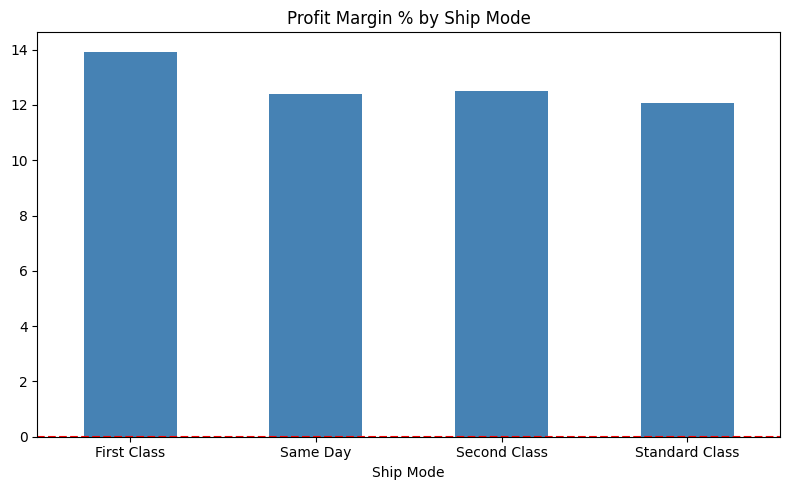

In [28]:
df_shipmode['Profit Margin %'].plot(kind='bar', figsize=(8,5), color='steelblue')
plt.title('Profit Margin % by Ship Mode')
plt.xticks(rotation=0)
plt.axhline(y=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### Ship mode has very little impact on profitability as all four modes cluster within a 2% margin range. This suggests that shipping costs are not a major driver of profit loss in this dataset.

### 9. Can we predict profits of a category based on discount?

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df[['Discount']]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.0637
RMSE: 213.06


In [42]:
for category in df['Category'].unique():
    df_cat = df[df['Category'] == category]
    X_cat = df_cat[['Discount']]
    y_cat = df_cat['Profit']
    
    X_train, X_test, y_train, y_test = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"{category} — R²: {r2_score(y_test, y_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Furniture — R²: 0.2343, RMSE: 117.04
Office Supplies — R²: 0.0363, RMSE: 200.08
Technology — R²: 0.1208, RMSE: 244.95


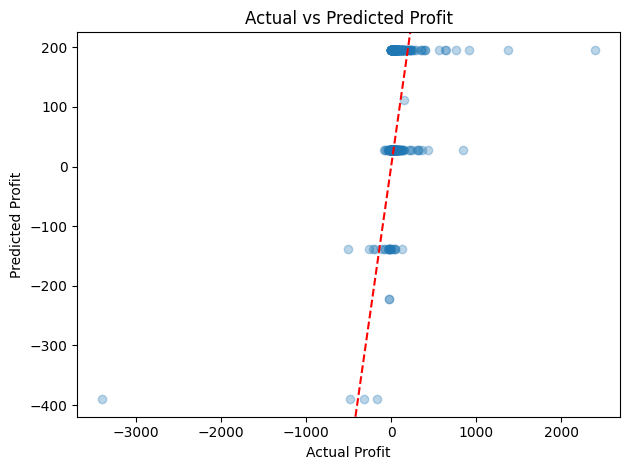

In [43]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.axline((0,0), slope=1, color='red', linestyle='--')  # perfect prediction line
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit')
plt.tight_layout()
plt.show()

### Discount alone is a weak predictor of profit across all categories. Furniture shows the strongest relationship (R²: 0.23). However, no category reaches a reliable R², meaning profit is driven by many other factors beyond discount alone.